# Sample Marketing Mix Model (MMM) 

This notebook builds a Marketing Mix Model on the weekly `monthly_mocha.csv` data.

**Pipeline** (mirrors Google Meridian's approach):
1. Load & explore the data
2. Apply **adstock** (geometric carry-over) to media impressions
3. Apply **Hill saturation** curves
4. Fit a linear regression of transformed media → subscriptions
5. Decompose channel contributions & compute **ROI**
6. Plot response curves
7. **Budget optimization**

In [1]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots
from scipy.optimize import minimize, differential_evolution
from sklearn.linear_model import Ridge
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import r2_score, mean_absolute_percentage_error
import statsmodels.api as sm

## 1. Load & Explore Data

In [2]:
df = pd.read_csv('../data/monthly_mocha.csv')
df['date'] = pd.to_datetime(df['date'])
df = df.sort_values('date').reset_index(drop=True)

print(f"Shape: {df.shape}")
print(f"Date range: {df['date'].min().date()} → {df['date'].max().date()}")
print(f"\nSubscriptions — mean: {df['subscriptions'].mean():.0f}, "
      f"min: {df['subscriptions'].min()}, max: {df['subscriptions'].max()}")
df.head()

Shape: (74, 20)
Date range: 2024-03-11 → 2025-08-04

Subscriptions — mean: 12388, min: 8427, max: 20113


,date,subscriptions,meta_spend,meta_impressions,google_spend,google_impressions,snapchat_spend,snapchat_impressions,tiktok_spend,tiktok_impressions,moloco_spend,moloco_impressions,liveintent_spend,liveintent_impressions,roku_spend,roku_impressions,beehiiv_spend,beehiiv_impressions,amazon_spend,amazon_impressions
0,2024-03-11,8466,24453.32013,7003930,48184.00505,2686578,54700.64863,2266423,0.0,0,23641.676810,1246014,3285.905595,47267,0,0,0.0,0,0.0,0
1,2024-03-18,11438,12056.40304,3802326,43667.36138,2090050,60680.82970,3491582,0.0,0,9275.368834,301812,4060.587295,39311,0,0,0.0,0,0.0,0
2,2024-03-25,10697,0.00000,0,44484.47785,2426908,72718.80076,2816049,0.0,0,6295.163207,209783,4437.924958,61860,0,0,0.0,0,0.0,0
3,2024-04-01,11401,0.00000,0,50505.08565,3033946,73616.60488,4104614,0.0,0,4828.646059,223832,4463.799368,53412,0,0,0.0,0,0.0,0
4,2024-04-08,12042,0.00000,0,55324.65109,2889430,60141.06131,2878530,0.0,0,12370.873120,411710,6375.286002,86952,0,0,0.0,0,0.0,0


In [3]:
spend_cols = [c for c in df.columns if c.endswith('_spend')]
imp_cols   = [c for c in df.columns if c.endswith('_impressions')]
channels   = [c.replace('_spend', '') for c in spend_cols]

print(f"Channels detected: {channels}")
print(f"\nTotal spend per channel:")
for ch in channels:
    total = df[f'{ch}_spend'].sum()
    active_weeks = (df[f'{ch}_spend'] > 0).sum()
    print(f"  {ch:>12s}: ${total:>12,.0f}  ({active_weeks}/{len(df)} active weeks)")

Channels detected: ['meta', 'google', 'snapchat', 'tiktok', 'moloco', 'liveintent', 'roku', 'beehiiv', 'amazon']

Total spend per channel:
          meta: $     840,158  (19/74 active weeks)
        google: $  10,298,544  (74/74 active weeks)
      snapchat: $   4,342,437  (74/74 active weeks)
        tiktok: $   1,752,685  (39/74 active weeks)
        moloco: $     842,235  (74/74 active weeks)
    liveintent: $     797,987  (74/74 active weeks)
          roku: $           0  (0/74 active weeks)
       beehiiv: $     328,172  (25/74 active weeks)
        amazon: $      15,740  (3/74 active weeks)


In [4]:
# Drop channels with zero spend (roku has no activity)
active_channels = [ch for ch in channels if df[f'{ch}_spend'].sum() > 0]
print(f"Active channels: {active_channels}")

# Further filter: require at least 10 active weeks for reliable estimation
MIN_ACTIVE_WEEKS = 10
model_channels = [ch for ch in active_channels
                  if (df[f'{ch}_spend'] > 0).sum() >= MIN_ACTIVE_WEEKS]
print(f"Channels for modelling (≥{MIN_ACTIVE_WEEKS} active weeks): {model_channels}")

Active channels: ['meta', 'google', 'snapchat', 'tiktok', 'moloco', 'liveintent', 'beehiiv', 'amazon']
Channels for modelling (≥10 active weeks): ['meta', 'google', 'snapchat', 'tiktok', 'moloco', 'liveintent', 'beehiiv']


In [5]:
fig = make_subplots(rows=2, cols=1, shared_xaxes=True,
                    subplot_titles=['Weekly Subscriptions', 'Weekly Spend by Channel'])

fig.add_trace(go.Scatter(x=df['date'], y=df['subscriptions'],
                         mode='lines+markers', name='Subscriptions'),
              row=1, col=1)

for ch in model_channels:
    fig.add_trace(go.Scatter(x=df['date'], y=df[f'{ch}_spend'],
                             mode='lines', name=ch, stackgroup='spend'),
                  row=2, col=1)

fig.update_layout(height=600, title_text='Mocha — KPI & Media Spend Over Time')
fig.show()

## 2. Adstock & Saturation Transforms

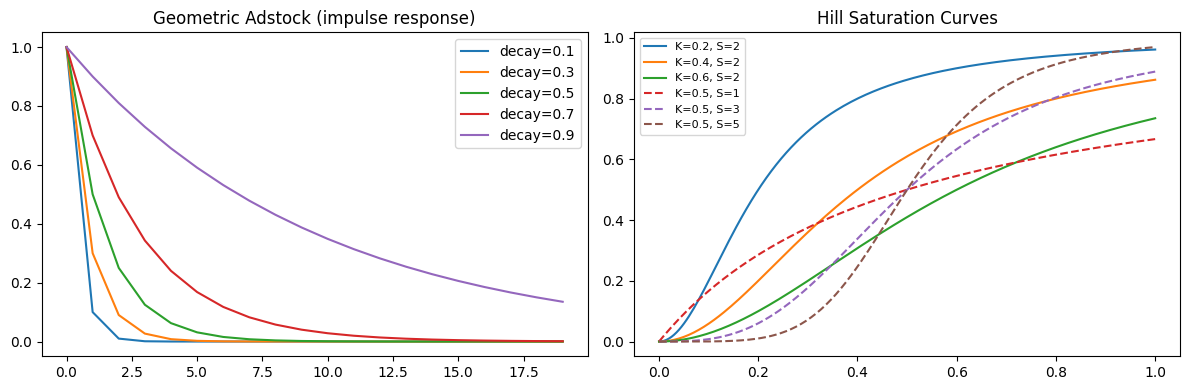

In [6]:
def geometric_adstock(x: np.ndarray, decay: float) -> np.ndarray:
    """Apply geometric (carry-over) adstock with retention rate `decay` ∈ [0,1)."""
    out = np.zeros_like(x, dtype=float)
    out[0] = x[0]
    for t in range(1, len(x)):
        out[t] = x[t] + decay * out[t - 1]
    return out


def hill_saturation(x: np.ndarray, K: float, S: float) -> np.ndarray:
    """Hill function: response = x^S / (K^S + x^S).  K = half-saturation, S = slope."""
    return np.power(x, S) / (np.power(K, S) + np.power(x, S) + 1e-15)


# Quick visual check
x_demo = np.linspace(0, 1, 200)
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

for d in [0.1, 0.3, 0.5, 0.7, 0.9]:
    impulse = np.zeros(20); impulse[0] = 1.0
    axes[0].plot(geometric_adstock(impulse, d), label=f'decay={d}')
axes[0].set_title('Geometric Adstock (impulse response)')
axes[0].legend()

for K in [0.2, 0.4, 0.6]:
    axes[1].plot(x_demo, hill_saturation(x_demo, K, S=2.0), label=f'K={K}, S=2')
for S in [1, 3, 5]:
    axes[1].plot(x_demo, hill_saturation(x_demo, 0.5, S), '--', label=f'K=0.5, S={S}')
axes[1].set_title('Hill Saturation Curves')
axes[1].legend(fontsize=8)

plt.tight_layout()
plt.show()

## 3. Fit the MMM

For each channel we jointly optimise:
- **decay** (adstock retention)
- **K** (half-saturation point)
- **S** (Hill slope)

Outer loop: `scipy.optimize.differential_evolution` searches over (decay, K, S) per channel.  
Inner loop: Ridge regression maps transformed media → subscriptions.

In [7]:
imp_data = {}
spend_data = {}
for ch in model_channels:
    imp_data[ch] = df[f'{ch}_impressions'].values.astype(float)
    spend_data[ch] = df[f'{ch}_spend'].values.astype(float)

y = df['subscriptions'].values.astype(float)
n_obs = len(y)
n_ch  = len(model_channels)

scaler = MinMaxScaler()
imp_scaled = {}
for ch in model_channels:
    vals = imp_data[ch].reshape(-1, 1)
    imp_scaled[ch] = scaler.fit_transform(vals).ravel()

print(f"Observations: {n_obs}, Channels: {n_ch}")

Observations: 74, Channels: 7


In [8]:
def build_X(params_flat, channels, imp_scaled_dict, n_obs):
    """
    Given a flat vector of [decay_1, K_1, S_1, decay_2, K_2, S_2, ...],
    return the (n_obs x n_ch) transformed-media matrix.
    """
    X = np.zeros((n_obs, len(channels)))
    for i, ch in enumerate(channels):
        decay, K, S = params_flat[3*i : 3*i+3]
        adstocked = geometric_adstock(imp_scaled_dict[ch], decay)
        saturated = hill_saturation(adstocked, K, S)
        X[:, i] = saturated
    return X


def objective(params_flat):
    """Negative R² (we minimise)."""
    X = build_X(params_flat, model_channels, imp_scaled, n_obs)
    X_with_const = sm.add_constant(X)
    ridge = Ridge(alpha=1.0, fit_intercept=False)
    ridge.fit(X_with_const, y)
    y_pred = ridge.predict(X_with_const)
    return -r2_score(y, y_pred)


# Bounds: (decay, K, S) per channel
bounds = []
for _ in model_channels:
    bounds += [
        (0.01, 0.95),   # decay
        (0.05, 0.95),   # K (half-sat, on 0-1 scaled impressions)
        (0.5,  4.0),    # S (Hill slope)
    ]

print(f"Optimising {len(bounds)} parameters ({n_ch} channels × 3 transform params)…")
result = differential_evolution(
    objective, bounds,
    seed=42, maxiter=300, tol=1e-6,
    polish=True, workers=1,
    disp=False,
)
print(f"Best R² = {-result.fun:.4f}")

Optimising 21 parameters (7 channels × 3 transform params)…


Best R² = 0.8494


In [9]:
best_params = result.x

transform_params = {}
print(f"{'Channel':>12s}  {'Decay':>6s}  {'K (half-sat)':>12s}  {'S (slope)':>9s}")
print('-' * 48)
for i, ch in enumerate(model_channels):
    d, K, S = best_params[3*i : 3*i+3]
    transform_params[ch] = {'decay': d, 'K': K, 'S': S}
    print(f"{ch:>12s}  {d:6.3f}  {K:12.3f}  {S:9.3f}")

     Channel   Decay  K (half-sat)  S (slope)
------------------------------------------------
        meta   0.500         0.556      4.000
      google   0.423         0.950      4.000
    snapchat   0.667         0.557      4.000
      tiktok   0.010         0.746      4.000
      moloco   0.195         0.370      4.000
  liveintent   0.171         0.950      4.000
     beehiiv   0.338         0.123      0.500


In [10]:
# Final regression with best transforms
X_best = build_X(best_params, model_channels, imp_scaled, n_obs)
X_best_c = sm.add_constant(X_best)

ols_model = sm.OLS(y, X_best_c).fit()
print(ols_model.summary(xname=['intercept'] + model_channels))

                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.864
Model:                            OLS   Adj. R-squared:                  0.850
Method:                 Least Squares   F-statistic:                     59.90
Date:                Wed, 22 Apr 2026   Prob (F-statistic):           3.82e-26
Time:                        16:11:47   Log-Likelihood:                -611.11
No. Observations:                  74   AIC:                             1238.
Df Residuals:                      66   BIC:                             1257.
Df Model:                           7                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
intercept   7985.9940    603.870     13.225      0.0

In [11]:
y_pred = ols_model.predict(X_best_c)
r2  = r2_score(y, y_pred)
mape = mean_absolute_percentage_error(y, y_pred)

fig = go.Figure()
fig.add_trace(go.Scatter(x=df['date'], y=y, mode='lines+markers', name='Actual'))
fig.add_trace(go.Scatter(x=df['date'], y=y_pred, mode='lines', name='Predicted',
                         line=dict(dash='dash')))
fig.update_layout(title=f'Actual vs Predicted Subscriptions  (R²={r2:.3f}, MAPE={mape:.1%})',
                  yaxis_title='Subscriptions')
fig.show()

## 4. Channel Contributions & ROI

In [12]:
coeffs = ols_model.params[1:]  # exclude intercept
intercept = ols_model.params[0]

contributions = {}
for i, ch in enumerate(model_channels):
    contributions[ch] = coeffs[i] * X_best[:, i]

contrib_df = pd.DataFrame(contributions, index=df['date'])
contrib_df['base'] = intercept
contrib_totals = contrib_df.sum()

print("Total contribution (subscriptions driven):")
print(contrib_totals.sort_values(ascending=False).to_string())
print(f"\nSum = {contrib_totals.sum():.0f}  vs  actual total = {y.sum():.0f}")

Total contribution (subscriptions driven):
base          590963.557249
snapchat      170498.583183
beehiiv        77501.048700
moloco         27611.870792
google         21045.703736
tiktok         12223.611605
liveintent     11855.080595
meta            4990.544139

Sum = 916690  vs  actual total = 916690


In [13]:
total_spend = {ch: df[f'{ch}_spend'].sum() for ch in model_channels}
total_contrib = {ch: contributions[ch].sum() for ch in model_channels}

roi = {}
cpa = {}
for ch in model_channels:
    s = total_spend[ch]
    c = total_contrib[ch]
    roi[ch] = c / s if s > 0 else 0
    cpa[ch] = s / c if c > 0 else float('inf')

roi_df = pd.DataFrame({
    'channel': model_channels,
    'total_spend': [total_spend[ch] for ch in model_channels],
    'total_subscriptions': [total_contrib[ch] for ch in model_channels],
    'roi_subs_per_dollar': [roi[ch] for ch in model_channels],
    'cpa': [cpa[ch] for ch in model_channels],
}).sort_values('roi_subs_per_dollar', ascending=False)

print(roi_df.to_string(index=False, float_format='%.4f'))

   channel   total_spend  total_subscriptions  roi_subs_per_dollar      cpa
   beehiiv   328172.2733           77501.0487               0.2362   4.2344
  snapchat  4342436.9090          170498.5832               0.0393  25.4690
    moloco   842234.6096           27611.8708               0.0328  30.5026
liveintent   797987.1731           11855.0806               0.0149  67.3118
    tiktok  1752685.0091           12223.6116               0.0070 143.3852
      meta   840158.1265            4990.5441               0.0059 168.3500
    google 10298543.9467           21045.7037               0.0020 489.3419


In [14]:
fig = make_subplots(rows=1, cols=2,
                    subplot_titles=['ROI (subs per $1 spent)', 'Cost per Acquisition ($)'])

sorted_roi = roi_df.sort_values('roi_subs_per_dollar', ascending=True)
fig.add_trace(go.Bar(y=sorted_roi['channel'],
                     x=sorted_roi['roi_subs_per_dollar'],
                     orientation='h', marker_color='steelblue'),
              row=1, col=1)

sorted_cpa = roi_df.sort_values('cpa', ascending=False)
fig.add_trace(go.Bar(y=sorted_cpa['channel'],
                     x=sorted_cpa['cpa'],
                     orientation='h', marker_color='indianred'),
              row=1, col=2)

fig.update_layout(height=400, showlegend=False,
                  title_text='Channel Efficiency')
fig.show()

In [15]:
# Stacked contribution over time
fig = go.Figure()
fig.add_trace(go.Scatter(x=df['date'], y=[intercept]*n_obs,
                         mode='lines', name='base', stackgroup='one'))
for ch in model_channels:
    fig.add_trace(go.Scatter(x=df['date'], y=contributions[ch],
                             mode='lines', name=ch, stackgroup='one'))

fig.add_trace(go.Scatter(x=df['date'], y=y, mode='markers',
                         name='actual', marker=dict(color='black', size=4)))
fig.update_layout(title='Subscription Decomposition Over Time',
                  yaxis_title='Subscriptions', height=500)
fig.show()

## 5. Response Curves

In [16]:
fig = make_subplots(rows=2, cols=4,
                    subplot_titles=[ch for ch in model_channels])

for idx, ch in enumerate(model_channels):
    row = idx // 4 + 1
    col = idx % 4 + 1
    p = transform_params[ch]
    x_range = np.linspace(0, 1, 200)
    adstocked = geometric_adstock(x_range, p['decay'])
    saturated = hill_saturation(adstocked, p['K'], p['S'])
    response  = coeffs[idx] * saturated

    # Map x_range back to spend-equivalent for interpretability
    max_spend = df[f'{ch}_spend'].max()
    x_spend = x_range * max_spend

    fig.add_trace(go.Scatter(x=x_spend, y=response, mode='lines',
                             showlegend=False),
                  row=row, col=col)

fig.update_layout(height=500, title_text='Response Curves by Channel')
fig.show()

## 6. Budget Optimization

Given the current total budget, find the allocation across channels that **maximises predicted subscriptions**.

In [17]:
total_budget = sum(total_spend[ch] for ch in model_channels)
print(f"Current total budget: ${total_budget:,.0f}")

# Mean spend→impressions ratio per channel (for converting budget to impressions)
spend_to_imp = {}
for ch in model_channels:
    mask = df[f'{ch}_spend'] > 0
    if mask.sum() > 0:
        spend_to_imp[ch] = (df.loc[mask, f'{ch}_impressions'] /
                            df.loc[mask, f'{ch}_spend']).median()
    else:
        spend_to_imp[ch] = 0

imp_maxes = {ch: imp_data[ch].max() for ch in model_channels}


def predict_from_budget(budget_alloc):
    """Predict total subscriptions for a given per-channel weekly-average budget vector."""
    total_subs = intercept * n_obs
    for i, ch in enumerate(model_channels):
        weekly_spend = budget_alloc[i]
        weekly_imp   = weekly_spend * spend_to_imp[ch]
        imp_norm     = weekly_imp / (imp_maxes[ch] + 1e-15)
        imp_norm     = min(imp_norm, 1.0)
        p = transform_params[ch]
        adstocked = geometric_adstock(np.full(n_obs, imp_norm), p['decay'])
        saturated = hill_saturation(adstocked, p['K'], p['S'])
        total_subs += coeffs[i] * saturated.sum()
    return total_subs


current_weekly = np.array([total_spend[ch] / n_obs for ch in model_channels])
current_pred   = predict_from_budget(current_weekly)
print(f"Predicted subs with current allocation: {current_pred:,.0f}")

Current total budget: $19,202,218
Predicted subs with current allocation: 1,009,220


In [18]:
weekly_budget = total_budget / n_obs

def neg_subs(alloc):
    return -predict_from_budget(alloc)

constraints = [{'type': 'eq', 'fun': lambda a: a.sum() - weekly_budget}]
opt_bounds  = [(0, weekly_budget) for _ in model_channels]

opt_result = minimize(
    neg_subs,
    x0=current_weekly,
    method='SLSQP',
    bounds=opt_bounds,
    constraints=constraints,
    options={'maxiter': 1000, 'ftol': 1e-10},
)

optimized_weekly = opt_result.x
optimized_pred   = predict_from_budget(optimized_weekly)

print(f"Optimized predicted subs: {optimized_pred:,.0f}")
print(f"Lift over current:        {(optimized_pred/current_pred - 1)*100:+.1f}%")

Optimized predicted subs: 1,340,930
Lift over current:        +32.9%


In [19]:
opt_df = pd.DataFrame({
    'channel': model_channels,
    'current_weekly_spend': current_weekly,
    'optimized_weekly_spend': optimized_weekly,
    'change_pct': (optimized_weekly / (current_weekly + 1e-9) - 1) * 100,
})

print(opt_df.to_string(index=False, float_format='%.1f'))

fig = go.Figure()
fig.add_trace(go.Bar(name='Current', x=opt_df['channel'],
                     y=opt_df['current_weekly_spend']))
fig.add_trace(go.Bar(name='Optimized', x=opt_df['channel'],
                     y=opt_df['optimized_weekly_spend']))
fig.update_layout(barmode='group',
                  title='Current vs Optimized Weekly Budget Allocation',
                  yaxis_title='Weekly Spend ($)')
fig.show()

   channel  current_weekly_spend  optimized_weekly_spend  change_pct
      meta               11353.5                     0.0      -100.0
    google              139169.5                  6470.1       -95.4
  snapchat               58681.6                118827.0       102.5
    tiktok               23684.9                     0.0      -100.0
    moloco               11381.5                100011.7       778.7
liveintent               10783.6                     0.0      -100.0
   beehiiv                4434.8                 34180.7       670.7


In [20]:
print("\n" + "="*60)
print("MMM SUMMARY")
print("="*60)
print(f"Model fit:  R² = {r2:.3f},  MAPE = {mape:.1%}")
print(f"Channels:   {len(model_channels)}")
print(f"Obs:        {n_obs} weeks")
print(f"\nTop 3 ROI channels:")
for _, row in roi_df.head(3).iterrows():
    print(f"  {row['channel']:>12s}  ROI={row['roi_subs_per_dollar']:.4f} subs/$  "
          f"CPA=${row['cpa']:.2f}")
print(f"\nBudget optimization lift: {(optimized_pred/current_pred - 1)*100:+.1f}%")
print("="*60)


MMM SUMMARY
Model fit:  R² = 0.864,  MAPE = 6.3%
Channels:   7
Obs:        74 weeks

Top 3 ROI channels:
       beehiiv  ROI=0.2362 subs/$  CPA=$4.23
      snapchat  ROI=0.0393 subs/$  CPA=$25.47
        moloco  ROI=0.0328 subs/$  CPA=$30.50

Budget optimization lift: +32.9%
